In [1]:
import torchvision
from torchvision import transforms
import torch

import matplotlib.pyplot as plt

In [13]:
batch_size = 64
trainset = torchvision.datasets.MNIST(root='./data/', train=True, download=True, transform=transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.MNIST(root='./data/', train=False, download=True, transform=transforms.ToTensor())
test_loader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

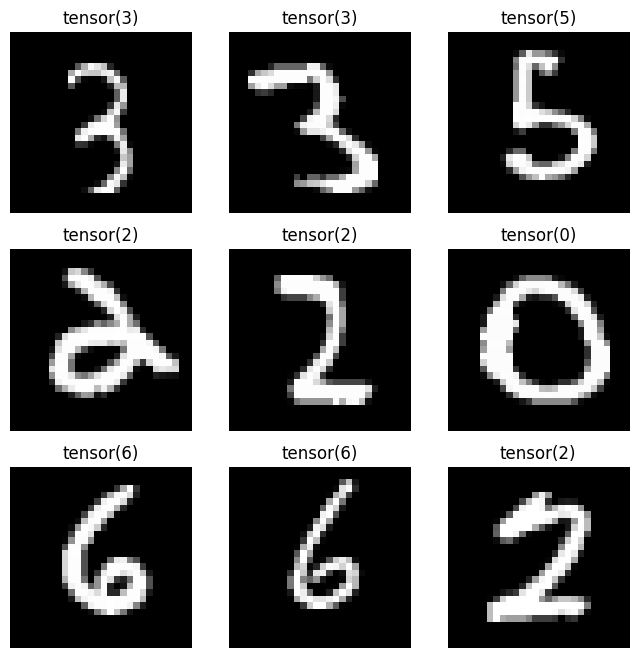

In [14]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = next(iter(train_loader))
    figure.add_subplot(rows, cols, i)
    plt.title(label[0])
    plt.axis("off")
    plt.imshow(img[0].squeeze(), cmap="gray")
plt.show()

In [15]:
import torch.nn as nn

# Define the model
class MLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 32)
        self.fc4 = nn.Linear(32, num_classes)

        self.bn1 = nn.BatchNorm1d(128)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(32)
        self.bn4 = nn.BatchNorm1d(num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        # Flatten the input tensor
        x = x.view(x.size(0), -1)

        # Layer 1
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # Layer 2
        out = self.fc2(out)
        out = self.bn2(out)
        out = self.relu(out)

        # Layer 3
        out = self.fc3(out)
        out = self.bn3(out)
        out = self.relu(out)

        # Layer 4
        out = self.fc4(out)
        out = self.bn4(out)
        out = self.relu(out)

        # Output
        out = nn.functional.softmax(out, dim=1)

        return out

In [ ]:
model = MLP(28*28, 10)

# Define the loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0002)

# Train the model
# Track the losses at each epoch
losses = []
test_losses = []
num_epochs = 500
for epoch in range(num_epochs):
    for i, (features, labels) in enumerate(train_loader):

        # Forward pass
        outputs = model(features)
        loss = loss_fn(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Save the loss value at this epoch
    losses.append(loss.item())

    if (epoch + 1) % 2 == 0:
        # Print the loss value at the end of each epoch
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

    # Test the model
    with torch.no_grad():
        for features, labels in test_loader:
            outputs = model(features)
            test_loss = loss_fn(outputs, labels)
        test_losses.append(test_loss.item())

# Plot the loss curve
plt.plot(losses, label='Train')
plt.plot(test_losses, label='Test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.gcf().set_facecolor('white')
#plt.savefig('loss_curve.png')
plt.show()

Epoch [2/500], Loss: 1.7420
Epoch [4/500], Loss: 1.5915
Epoch [6/500], Loss: 1.5513
Epoch [8/500], Loss: 1.5535
Epoch [10/500], Loss: 1.4797
Epoch [12/500], Loss: 1.4778
Epoch [14/500], Loss: 1.5043
Epoch [16/500], Loss: 1.4990
Epoch [18/500], Loss: 1.4707
Epoch [20/500], Loss: 1.4872
Epoch [22/500], Loss: 1.4780
Epoch [24/500], Loss: 1.4667
Epoch [26/500], Loss: 1.5223
Epoch [28/500], Loss: 1.4891
Epoch [30/500], Loss: 1.4690
Epoch [32/500], Loss: 1.4677
Epoch [34/500], Loss: 1.4632
Epoch [36/500], Loss: 1.4980
Epoch [38/500], Loss: 1.4699
Epoch [40/500], Loss: 1.4974
Epoch [42/500], Loss: 1.4617
Epoch [44/500], Loss: 1.4666
Epoch [46/500], Loss: 1.4632
Epoch [48/500], Loss: 1.4800
Epoch [50/500], Loss: 1.4617
Epoch [52/500], Loss: 1.4638
Epoch [54/500], Loss: 1.4621
Epoch [56/500], Loss: 1.4635
Epoch [58/500], Loss: 1.4618
Epoch [60/500], Loss: 1.4935
Epoch [62/500], Loss: 1.4627
Epoch [64/500], Loss: 1.4622
Epoch [66/500], Loss: 1.4620
Epoch [68/500], Loss: 1.4655
Epoch [70/500], Lo